In [6]:
""" ▶ QUANTUM COIN ◀ """

' ▶ QUANTUM COIN ◀ '

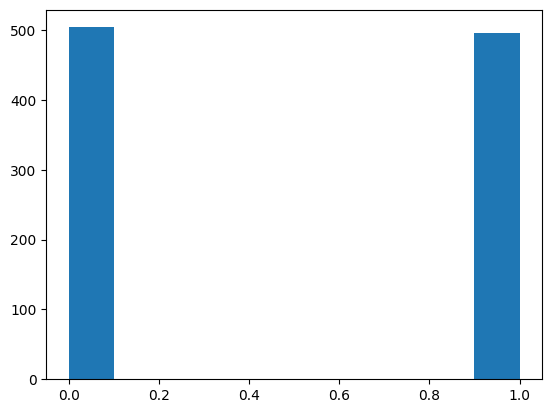

In [7]:
"""CALSSICAL COIN FLIP SIMULATION"""
import numpy as np
import matplotlib.pyplot as plt
import random


nflips = 1000
fliplist = [random.randint(0, 1) for f in range(nflips)]


# bar plots using get_gaussian_probs function
plt.hist(fliplist)
plt.show()

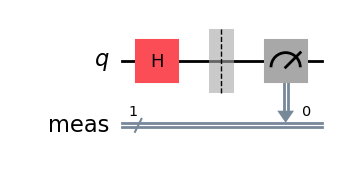

In [8]:
from qiskit import QuantumCircuit

qcoin = QuantumCircuit(1)
qcoin.h(0)
qcoin.measure_all()

qcoin.draw("mpl")

In [9]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

from qiskit_ibm_runtime import (
    SamplerV2 as Sampler,
    EstimatorV2 as Estimator,
)

# Use the least busy backend
backend = service.least_busy()
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-07-11 20:49:56,895: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: seolwon64. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-11 20:49:57,309: Using instance: seolwon64, plan: open


ibm_marrakesh


In [10]:
""" AER SIMULATOR IF THE BACKEND IS QUITE BUSY : ALTERNATIVE """

# from qiskit_aer import AerSimulator

## Generate a simulator that mimics the real quantum system

# backend_sim = AerSimulator.from_backend(backend)

## Import an estimator, this time from qiskit (we will import from Runtime for real hardware)

# from qiskit.primitives import BackendSamplerV2
# sampler_sim = BackendSamplerV2(backend = backend_sim)
# from qiskit.primitives import BackendEstimatorV2
# estimator_sim = BackendEstimatorV2(backend = backend_sim)

' AER SIMULATOR IF THE BACKEND IS QUITE BUSY : ALTERNATIVE '

In [11]:
""" TRANSPILE """
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qcoin)

In [ ]:
""" EXECUTE """

# On real hardware:
sampler = Sampler(mode=backend)
pubs = [qc_isa]
job = sampler.run(pubs, shots=1000)
res = job.result()

counts = res[0].data.meas.get_counts()

# or with Aer simulator with noise model from real backend
## job = sampler_sim.run([qc_isa])
## counts=job.result()[0].data.meas.get_counts()

from qiskit.visualization import plot_histogram

plot_histogram(counts)

In [ ]:
from qiskit.quantum_info import Pauli

qcoin = QuantumCircuit(1)
qcoin.h(0)

# for Estimator, we do not apply the measurement to the circuit

In [ ]:
""" TRANSPILE """
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

obs = Pauli("Z")

qc_isa = pm.run(qcoin)
obs_isa = obs.apply_layout(layout=qc_isa.layout)

In [ ]:
""" EXECUTE """

# On real hardware:
estimator = Estimator(mode=backend)
pubs = [(qc_isa, obs_isa)]
job = estimator.run([[qc_isa, obs_isa]])
res = job.result()

# On a simulator:
# job = estimator_sim.run([[qc_isa, obs_isa]])
# res=job.result()

print(res[0].data.evs)

In [ ]:
""" ▶ QUANTUM COIN IN 3D◀ """

In [ ]:
# Step 1: map problem

qcoin_lr = QuantumCircuit(1) # LEFT N RIGHT
qcoin_lr.h(0)

obs = Pauli("X")


# Step 2: Transpile the circuit
# SAMPLER WORKS ONLY IN 2D → ESTIMATOR WORKS IN 3D 

pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qcoin_lr)
obs_isa = obs.apply_layout(layout=qc_isa.layout)

# Step 3: Run the circuit on a real quantum computer

estimator = Estimator(mode=backend)
pubs = [(qc_isa, obs_isa)]
job = estimator.run([[qc_isa, obs_isa]])
res = job.result()

# Run the job on the Aer simulator with noise model from real backend
# job = estimator_sim.run([[qc_isa,obs_isa]])
# res=job.result()

# Step 4: Return the result in classical form, and analyze.

print(res[0].data.evs) # MEANS THAT THE COIN IS FAIR, 0.5 PROBABILITY OF LEFT AND RIGHT

In [ ]:
""" TWO HADAMARD GATES """

In [ ]:
qcoin_0 = QuantumCircuit(1)
qcoin_0.h(0)
qcoin_0.h(0)
qcoin_0.measure_all()

qcoin_0.draw("mpl")

In [ ]:
""" TRANSPILE """

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qcoin_0)

""" EXECUTE """

# On real hardware:
sampler = Sampler(mode=backend)
pubs = [qc_isa]
job = sampler.run(pubs, shots=1000)
res = job.result()

counts = res[0].data.meas.get_counts()


# or with Aer simulator with noise model from real backend
# job = sampler_sim.run([qc_isa])
# counts=job.result()[0].data.meas.get_counts()

## Analyze
plot_histogram(counts) #100% = 0

In [ ]:
qcoin_pi = QuantumCircuit(1)
qcoin_pi.h(0)
qcoin_pi.p(np.pi, 0) # PI = 180 DEGREES = FLIP COIN
qcoin_pi.h(0)
qcoin_pi.measure_all()

qcoin_pi.draw("mpl")

In [ ]:
""" TRANSPILE """

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qcoin_pi)

""" EXECUTE """

# On real hardware:
sampler = Sampler(mode=backend)
pubs = [qc_isa]
job = sampler.run(pubs, shots=1000)
res = job.result()

counts = res[0].data.meas.get_counts()


# or with Aer simulator with noise model from real backend
# job = sampler_sim.run([qc_isa])
# counts=job.result()[0].data.meas.get_counts()

## Analyze
plot_histogram(counts) # COUTCOME = 1

In [ ]:
"""25% = 0, 75% = 1"""
qcoin_phase = QuantumCircuit(1)
qcoin_phase.h(0)
qcoin_phase.rz(2 * np.pi / 3, 0) # 2 * np.pi / 3 = 120 DEGREES = 25% = 0, 75% = 1
qcoin_phase.h(0)
qcoin_phase.measure_all()


## Transpile

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qcoin_phase)

## Execute

# On real hardware:
sampler = Sampler(mode=backend)
pubs = [qc_isa]
job = sampler.run(pubs, shots=1000)
res = job.result()

counts = res[0].data.meas.get_counts()


# or with Aer simulator with noise model from real backend
# job = sampler_sim.run([qc_isa])
# counts=job.result()[0].data.meas.get_counts()

## Analyze
plot_histogram(counts)

NameError: name 'QuantumCircuit' is not defined